# 03 — MIDAS (Weekly, EXOG + Macro + Sentiment)

Mixed-Data Sampling regression for **weekly** silver log-returns. Aggregates the
daily target to W-FRI to match the other weekly notebooks (`04_random_forest`,
`05_xgboost`, `06_lstm`) so results are directly comparable.

**Path B alignment** (see `CLAUDE.md` §6 for context):

- Target: weekly silver log-return (Friday-to-Friday), same `train.csv`/`val.csv`/`test.csv`
  split as the other weekly notebooks.
- `EXOG` base = 3 silver autocorrelation lags + 6 cross-asset weekly lagged returns
  (gold, USD, copper, S&P500, VIX, oil). Identical to RF/XGBoost.
- **MIDAS-native contribution**: monthly macro variables (CPI, fed funds, industrial
  production, real rates) enter through **Beta-weighted lag polynomials** —
  3 monthly lags per variable, weights driven by 2 shape parameters $(\theta_1,\theta_2)$.
  This is what makes the model a MIDAS rather than just an ADL.
- Variant ladder: `EXOG → EXOG+Macro → EXOG+Reddit → EXOG+News → EXOG+Reddit+News → EXOG+Macro+Sentiment`.
- Naïve $y_{t-1}$ baseline, Diebold-Mariano vs `EXOG`, period breakdown, 2026 zoom — all
  matching the other weekly notebooks via the shared `eval_utils` conventions.


## Setup

In [58]:
suppressPackageStartupMessages({
  library(midasr)
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(zoo)
})

# ── Evaluation metrics (match Python eval_utils.py exactly) ──────────────────
rmse <- function(a, p) sqrt(mean((a - p)^2, na.rm = TRUE))
mae  <- function(a, p) mean(abs(a - p),      na.rm = TRUE)
da   <- function(a, p) mean(sign(a) == sign(p), na.rm = TRUE)
wda  <- function(a, p) {
  ok <- sign(a) == sign(p)
  sum(abs(a) * ok, na.rm = TRUE) / sum(abs(a), na.rm = TRUE)
}
eval_model <- function(name, actual, pred) {
  cat(sprintf("%-30s  RMSE=%.6f  MAE=%.6f  DA=%.3f  WDA=%.3f\n",
              name, rmse(actual, pred), mae(actual, pred),
              da(actual, pred), wda(actual, pred)))
  data.frame(model = name,
             rmse = rmse(actual, pred), mae = mae(actual, pred),
             dir_acc = da(actual, pred), wda = wda(actual, pred),
             stringsAsFactors = FALSE)
}

# Diebold-Mariano (Newey-West lag-1) — mirrors src/eval_utils.diebold_mariano
diebold_mariano <- function(actual, pred1, pred2, name1, name2) {
  mask <- !is.na(pred1) & !is.na(pred2) & !is.na(actual)
  a <- actual[mask]; p1 <- pred1[mask]; p2 <- pred2[mask]
  e1 <- (a - p1)^2; e2 <- (a - p2)^2; d <- e1 - e2
  n  <- length(d); d_bar <- mean(d)
  gamma0 <- var(d, na.rm = TRUE)
  gamma1 <- if (n > 1) cov(d[-n], d[-1]) else 0
  var_d  <- (gamma0 + 2 * gamma1) / n
  if (var_d <= 0) {
    cat(sprintf("%s vs %s: variance non-positive, skipping\n", name1, name2)); return(invisible(NULL))
  }
  dm  <- d_bar / sqrt(var_d)
  pv  <- 2 * (1 - pnorm(abs(dm)))
  sig <- if (pv < 0.001) "***" else if (pv < 0.01) "**" else if (pv < 0.05) "*" else "(ns)"
  cat(sprintf("%-30s vs %-30s  DM=%+.3f  p=%.3f  %s\n", name1, name2, dm, pv, sig))
  if (pv < 0.05) {
    better <- if (dm < 0) name1 else name2
    cat(sprintf("  -> %s is significantly more accurate\n", better))
  }
}

cat("midasr:", as.character(packageVersion("midasr")), "\n")


midasr: 0.9 


## 1. Load & aggregate to weekly

Same input files as `04_random_forest.ipynb` / `05_xgboost.ipynb`. Daily returns
are summed to W-FRI (sums = log-return additivity); monthly macro is joined later
at its native frequency.

In [59]:
train <- read.csv("../../data/processed/train.csv", row.names = 1)
val   <- read.csv("../../data/processed/val.csv",   row.names = 1)
test  <- read.csv("../../data/processed/test.csv",  row.names = 1)

TARGET <- "silver_return"
EXOG   <- c("gold_return", "usd_return", "copper_return",
            "sp500_return", "vix_return", "oil_return")

# Friday-end weekly aggregation (matches pandas .resample('W-FRI').sum())
to_weekly <- function(df) {
  df$Date <- as.Date(rownames(df))
  # Day-of-week (Mon=1..Sun=7) → days to add to reach Friday of this week
  df$week_end <- df$Date + ((5 - as.integer(format(df$Date, "%u"))) %% 7)
  cols <- intersect(c(TARGET, EXOG), names(df))
  df %>%
    group_by(week_end) %>%
    summarise(across(all_of(cols), ~ sum(.x, na.rm = TRUE)), .groups = "drop") %>%
    rename(Date = week_end)
}

train_w <- to_weekly(train)
val_w   <- to_weekly(val)
test_w  <- to_weekly(test)

all_w   <- bind_rows(train_w, val_w, test_w) %>% arrange(Date)
n_train <- nrow(train_w) + nrow(val_w)

cat(sprintf("Weekly obs — train+val: %d, test: %d\n", n_train, nrow(test_w)))
cat("Cols:", paste(names(all_w), collapse = ", "), "\n")


Weekly obs — train+val: 417, test: 175
Cols: Date, silver_return, gold_return, usd_return, copper_return, sp500_return, vix_return, oil_return 


## 2. Build EXOG base predictors

Same lag structure as the tree-model notebooks: 3 silver autocorrelation lags +
1-week lag of each cross-asset return. All lags use only past information.

In [60]:
# Silver lags 1-3
for (k in 1:3) all_w[[paste0("silver_lag", k)]] <- dplyr::lag(all_w$silver_return, k)

# 1-week lag of each cross-asset
for (v in EXOG) {
  lag_name <- sub("_return", "_lag1", v)
  if (v %in% names(all_w)) all_w[[lag_name]] <- dplyr::lag(all_w[[v]], 1)
}

EXOG_LAGS <- c("silver_lag1", "silver_lag2", "silver_lag3",
               "gold_lag1", "usd_lag1", "copper_lag1",
               "sp500_lag1", "vix_lag1", "oil_lag1")
EXOG_LAGS <- intersect(EXOG_LAGS, names(all_w))
cat("EXOG base regressors (", length(EXOG_LAGS), "):", paste(EXOG_LAGS, collapse = ", "), "\n")


EXOG base regressors ( 9 ): silver_lag1, silver_lag2, silver_lag3, gold_lag1, usd_lag1, copper_lag1, sp500_lag1, vix_lag1, oil_lag1 


## 3. Monthly macro lag matrices (MIDAS predictors)

For each weekly Friday, collect the **3 most recent monthly observations** of each
macro variable that were *already released* by that date. These (N×3) matrices
feed into the Beta-weighted MIDAS columns later. `lag1` = most recent month available.

This is the mixed-frequency contribution: weekly target, monthly predictors, with
the lag polynomial doing the cross-frequency reduction.

In [61]:
macro <- read.csv("../../data/raw/monthly_macro.csv", row.names = 1)
macro$Date <- as.Date(rownames(macro))

MACRO_VARS    <- intersect(c("cpi", "fed_funds", "ind_prod", "real_rates"), names(macro))
N_MACRO_LAGS  <- 3

build_weekly_macro_lags <- function(weekly_dates, macro_df, var, n_lags) {
  mat <- matrix(NA_real_, nrow = length(weekly_dates), ncol = n_lags)
  for (i in seq_along(weekly_dates)) {
    past <- na.omit(macro_df[[var]][macro_df$Date < weekly_dates[i]])
    if (length(past) >= n_lags) mat[i, ] <- rev(tail(past, n_lags))
  }
  colnames(mat) <- paste0(var, "_mlag", seq_len(n_lags))
  mat
}

macro_lags <- lapply(MACRO_VARS, build_weekly_macro_lags,
                     weekly_dates = all_w$Date, macro_df = macro, n_lags = N_MACRO_LAGS)
names(macro_lags) <- MACRO_VARS

cat("Macro lag matrices built for:", paste(MACRO_VARS, collapse = ", "),
    "(", N_MACRO_LAGS, "monthly lags each)\n")


Macro lag matrices built for: cpi, fed_funds, ind_prod, real_rates ( 3 monthly lags each)


## 4. Weekly sentiment (lagged 1 week)

Aggregate daily Reddit + GDELT-news sentiment to W-FRI mean, forward-fill any gaps,
lag 1 week. Matches the sentiment treatment in `04_random_forest.ipynb` etc.

In [62]:
sent_path <- "../../data/processed/daily_sentiment.csv"
sentiment_available <- file.exists(sent_path)

ffill_zero <- function(x) { x <- zoo::na.locf(x, na.rm = FALSE); x[is.na(x)] <- 0; x }

if (sentiment_available) {
  sent <- read.csv(sent_path, row.names = 1)
  sent$Date <- as.Date(rownames(sent))
  sent$week_end <- sent$Date + ((5 - as.integer(format(sent$Date, "%u"))) %% 7)

  sent_cols <- intersect(c("reddit_sentiment", "news_sentiment"), names(sent))
  sent_w <- sent %>%
    group_by(week_end) %>%
    summarise(across(all_of(sent_cols), ~ mean(.x, na.rm = TRUE)), .groups = "drop") %>%
    rename(Date = week_end)

  aligned <- data.frame(Date = all_w$Date) %>% left_join(sent_w, by = "Date")

  if ("reddit_sentiment" %in% names(aligned)) {
    all_w$reddit_lag1 <- dplyr::lag(ffill_zero(aligned$reddit_sentiment), 1)
    all_w$reddit_lag1[is.na(all_w$reddit_lag1)] <- 0
  }
  if ("news_sentiment" %in% names(aligned)) {
    all_w$news_lag1 <- dplyr::lag(ffill_zero(aligned$news_sentiment), 1)
    all_w$news_lag1[is.na(all_w$news_lag1)] <- 0
  }
  cat("Sentiment merged. Columns added:",
      paste(intersect(c("reddit_lag1", "news_lag1"), names(all_w)), collapse = ", "), "\n")
} else {
  cat("daily_sentiment.csv not found — sentiment variants will be skipped.\n")
}


Sentiment merged. Columns added: reddit_lag1, news_lag1 


## 5. MIDAS helpers — Beta weights & joint fit

**Beta polynomial weights** $(\theta_1,\theta_2 > 0)$:
$$w_k = \frac{(k/K)^{\theta_1-1}(1-k/K)^{\theta_2-1}}{\sum_{j=1}^K (j/K)^{\theta_1-1}(1-j/K)^{\theta_2-1}}$$

`fit_with_midas()` jointly optimises Beta shape parameters across all macro variables
plus the OLS coefficients on the EXOG base. The objective is training MSE; constraints
are $\theta_{1,2} \ge 0.1$ (positivity) via L-BFGS-B.

A pure-OLS variant (no MIDAS) is just `lm()` on the EXOG base — used for the
`EXOG` and `EXOG+Sentiment` variants where no MIDAS weights need fitting.

In [63]:
# ── Beta polynomial weights (Ghysels et al. 2004) ────────────────────────────
nbeta_w <- function(k, theta) {
  th <- pmax(theta, 0.1)          # Beta needs positive shape params
  x  <- k / (max(k) + 1)
  w  <- x^(th[1] - 1) * (1 - x)^(th[2] - 1)
  w  <- pmax(w, 1e-10)
  w / sum(w)
}

# ── Normalised exponential Almon weights ────────────────────────────────────
nealmon_w <- function(k, theta) {
  w <- exp(theta[1] * k + theta[2] * k^2)
  w / sum(w)
}

# ── Restricted MIDAS (Beta or Almon) — joint NLS fit ─────────────────────────
fit_with_midas <- function(y, base_X, macro_list, weight_fn = nbeta_w,
                            start = NULL, lower = NULL) {
  vars   <- names(macro_list)
  nmacro <- length(vars)
  k_list <- lapply(macro_list, function(m) seq_len(ncol(m)))

  if (is.null(start)) start <- rep(c(1, 5), nmacro)    # Beta defaults
  if (is.null(lower)) lower <- rep(0.1, 2 * nmacro)

  obj <- function(theta_vec) {
    cols <- vector("list", nmacro)
    for (j in seq_len(nmacro)) {
      th <- theta_vec[(2 * j - 1):(2 * j)]
      cols[[j]] <- macro_list[[j]] %*% weight_fn(k_list[[j]], th)
    }
    midas_X <- do.call(cbind, cols)
    X <- cbind(1, as.matrix(base_X), midas_X)
    b <- tryCatch(solve(crossprod(X), crossprod(X, y)), error = function(e) NULL)
    if (is.null(b)) return(1e9)
    sum((y - X %*% b)^2)
  }

  opt <- optim(start, obj, method = "L-BFGS-B", lower = lower,
               control = list(maxit = 1000, factr = 1e7))

  theta_vec <- opt$par
  weights   <- list()
  cols_tr   <- vector("list", nmacro)
  for (j in seq_len(nmacro)) {
    th <- theta_vec[(2 * j - 1):(2 * j)]
    w  <- weight_fn(k_list[[j]], th)
    weights[[vars[j]]] <- w
    cols_tr[[j]]       <- macro_list[[j]] %*% w
  }
  midas_tr <- do.call(cbind, cols_tr); colnames(midas_tr) <- paste0(vars, "_midas")
  X_tr <- cbind(intercept = 1, as.matrix(base_X), midas_tr)
  b    <- as.vector(solve(crossprod(X_tr), crossprod(X_tr, y)))
  list(spec = "restricted", weights = weights, coefs = b, theta = theta_vec,
       converged = (opt$convergence == 0))
}

predict_with_midas <- function(fit, base_X, macro_list) {
  vars <- names(fit$weights)
  cols <- lapply(vars, function(v) macro_list[[v]] %*% fit$weights[[v]])
  midas_te <- do.call(cbind, cols); colnames(midas_te) <- paste0(vars, "_midas")
  X_te <- cbind(intercept = 1, as.matrix(base_X), midas_te)
  as.vector(X_te %*% fit$coefs)
}

# ── U-MIDAS (Foroni, Marcellino & Schumacher 2015): unrestricted per-lag OLS ──
fit_umidas <- function(y, base_X, macro_list) {
  M_stack <- do.call(cbind, macro_list)
  vnames  <- unlist(lapply(names(macro_list), function(v)
              paste0(v, "_mlag", seq_len(ncol(macro_list[[v]])))))
  colnames(M_stack) <- vnames
  X <- cbind(intercept = 1, as.matrix(base_X), M_stack)
  b <- as.vector(solve(crossprod(X), crossprod(X, y)))
  list(spec = "umidas", coefs = b, macro_names = vnames)
}

predict_umidas <- function(fit, base_X, macro_list) {
  M_stack <- do.call(cbind, macro_list)
  colnames(M_stack) <- fit$macro_names
  X <- cbind(intercept = 1, as.matrix(base_X), M_stack)
  as.vector(X %*% fit$coefs)
}

cat("MIDAS helpers defined (Beta, Almon, U-MIDAS).\n")


MIDAS helpers defined (Beta, Almon, U-MIDAS).


## 6. Two-stage protocol — spec selection, then ablation ladder

**Stage 1** picks the MIDAS weight family for the monthly macro lags by **val WDA**
(fit on train-only, score on 2022 val). All three candidates hold the EXOG+Macro
feature set fixed; only the macro lag weight scheme varies:

| Spec | Macro weight scheme | Params per macro variable |
|---|---|---|
| **U-MIDAS** | Unrestricted — one OLS coef per lag (Foroni, Marcellino & Schumacher 2015) | $K$ (= 3) |
| **Beta-MIDAS** | Beta polynomial $w_k(\theta_1,\theta_2)$ (Ghysels et al. 2004) | 2 + 1 coef |
| **Almon-MIDAS** | Exponential Almon $w_k(\theta_1,\theta_2)$ | 2 + 1 coef |

All three include EXOG's `silver_lag1/2/3`, so all three are ADL-MIDAS in the
Andreou/Ghysels/Kourtellos (2013) sense — the AR component lives in the base, and
"ADL-MIDAS" is not a separate spec here.

**Stage 2** runs the ablation ladder (same shape as RF / XGBoost / LSTM) using the
Stage-1 winner wherever macro enters. Sentiment-only variants are pure OLS (no
frequency mismatch to resolve).

| Variant | EXOG base | Macro (winning spec) | Sentiment |
|---|---|---|---|
| Naïve | — | — | — |
| EXOG | ✓ | | |
| EXOG+Macro | ✓ | ✓ | |
| EXOG+Reddit | ✓ | | Reddit |
| EXOG+News | ✓ | | News |
| EXOG+Reddit+News | ✓ | | Reddit + News |
| EXOG+Macro+Sentiment | ✓ | ✓ | Reddit + News |

**Honest caveat:** Stage 1 picks the spec on a single 52-week val window (2022). One
regime drives the choice. Walk-forward CV over train+val would be more robust, but
val-based selection keeps this notebook aligned with the LSTM convention.

In [64]:
# ─────────────────────────────────────────────────────────────────────────────
# STAGE 1 — Pick MIDAS weight family by val WDA (train-only → val)
# ─────────────────────────────────────────────────────────────────────────────

n_train_only <- nrow(train_w)   # rows of train_w alone (val starts at n_train_only + 1)

# Train+val and test partitions (all_w stacks train_w + val_w + test_w)
y_all_tr    <- all_w$silver_return[1:n_train]
y_test      <- all_w$silver_return[(n_train + 1):nrow(all_w)]
test_dates  <- all_w$Date[(n_train + 1):nrow(all_w)]
base_all_tr <- all_w[1:n_train,                EXOG_LAGS, drop = FALSE]
base_test   <- all_w[(n_train + 1):nrow(all_w), EXOG_LAGS, drop = FALSE]
macro_all_tr <- lapply(MACRO_VARS, function(v) macro_lags[[v]][1:n_train,                , drop = FALSE])
macro_test   <- lapply(MACRO_VARS, function(v) macro_lags[[v]][(n_train + 1):nrow(all_w), , drop = FALSE])
names(macro_all_tr) <- names(macro_test) <- MACRO_VARS

make_mask <- function(y, b, m_list)
  complete.cases(b) & !is.na(y) & Reduce(`&`, lapply(m_list, complete.cases))

# Stage-1 slices
idx_tr1 <- 1:n_train_only
y_tr1   <- y_all_tr[idx_tr1]
b_tr1   <- base_all_tr[idx_tr1, , drop = FALSE]
m_tr1   <- lapply(macro_all_tr, function(M) M[idx_tr1, , drop = FALSE])
mk_tr1  <- make_mask(y_tr1, b_tr1, m_tr1)
y_tr1   <- y_tr1[mk_tr1];  b_tr1 <- b_tr1[mk_tr1, , drop = FALSE]
m_tr1   <- lapply(m_tr1, function(M) M[mk_tr1, , drop = FALSE])

idx_v <- (n_train_only + 1):n_train
y_v   <- y_all_tr[idx_v]
b_v   <- base_all_tr[idx_v, , drop = FALSE]
m_v   <- lapply(macro_all_tr, function(M) M[idx_v, , drop = FALSE])
mk_v  <- make_mask(y_v, b_v, m_v)
y_v   <- y_v[mk_v];  b_v <- b_v[mk_v, , drop = FALSE]
m_v   <- lapply(m_v, function(M) M[mk_v, , drop = FALSE])

cat(sprintf("Stage 1 — train-only: %d obs   val: %d obs\n", length(y_tr1), length(y_v)))

k <- length(m_tr1)
fit_u_s1 <- fit_umidas    (y_tr1, b_tr1, m_tr1)
fit_b_s1 <- fit_with_midas(y_tr1, b_tr1, m_tr1, weight_fn = nbeta_w,
                            start = rep(c(1, 5), k), lower = rep( 0.1, 2 * k))
fit_a_s1 <- fit_with_midas(y_tr1, b_tr1, m_tr1, weight_fn = nealmon_w,
                            start = rep(c(0, 0), k), lower = rep(-5.0, 2 * k))

pred_u_v <- predict_umidas    (fit_u_s1, b_v, m_v)
pred_b_v <- predict_with_midas(fit_b_s1, b_v, m_v)
pred_a_v <- predict_with_midas(fit_a_s1, b_v, m_v)

cat("\nStage 1 — val WDA scores:\n")
stage1 <- rbind(
  eval_model("U-MIDAS",     y_v, pred_u_v),
  eval_model("Beta-MIDAS",  y_v, pred_b_v),
  eval_model("Almon-MIDAS", y_v, pred_a_v)
)
best_spec <- stage1$model[which.max(stage1$wda)]
cat("\n=> Winner by val WDA:", best_spec, "\n")
write.csv(stage1, "../../data/processed/midas_stage1_specs.csv", row.names = FALSE)

# ─────────────────────────────────────────────────────────────────────────────
# STAGE 2 — Variant ladder, refit on train+val with winning spec
# ─────────────────────────────────────────────────────────────────────────────

mask_train <- make_mask(y_all_tr, base_all_tr, macro_all_tr)
mask_test  <- make_mask(y_test,   base_test,   macro_test)
cat(sprintf("\nStage 2 — train+val: %d obs   test: %d obs\n", sum(mask_train), sum(mask_test)))

y_tr <- y_all_tr[mask_train];                   y_te <- y_test[mask_test]
b_tr <- base_all_tr[mask_train, , drop = FALSE]; b_te <- base_test[mask_test, , drop = FALSE]
m_tr <- lapply(macro_all_tr, function(M) M[mask_train, , drop = FALSE])
m_te <- lapply(macro_test,   function(M) M[mask_test,  , drop = FALSE])
dates_te <- test_dates[mask_test]

if (sentiment_available) {
  r_tr <- all_w$reddit_lag1[1:n_train][mask_train]
  r_te <- all_w$reddit_lag1[(n_train + 1):nrow(all_w)][mask_test]
  n_tr <- all_w$news_lag1  [1:n_train][mask_train]
  n_te <- all_w$news_lag1  [(n_train + 1):nrow(all_w)][mask_test]
}

# Dispatch on Stage 1 winner
fit_midas_dispatch <- function(y, base_X, macro_list) {
  kk <- length(macro_list)
  switch(best_spec,
    "U-MIDAS"     = fit_umidas(y, base_X, macro_list),
    "Beta-MIDAS"  = fit_with_midas(y, base_X, macro_list, weight_fn = nbeta_w,
                                    start = rep(c(1, 5), kk), lower = rep( 0.1, 2 * kk)),
    "Almon-MIDAS" = fit_with_midas(y, base_X, macro_list, weight_fn = nealmon_w,
                                    start = rep(c(0, 0), kk), lower = rep(-5.0, 2 * kk))
  )
}
predict_midas_dispatch <- function(fit, base_X, macro_list) {
  if (fit$spec == "umidas") predict_umidas(fit, base_X, macro_list)
  else                      predict_with_midas(fit, base_X, macro_list)
}

all_results <- list()
all_preds   <- list()

run_ols <- function(label, X_tr_var, X_te_var) {
  df   <- cbind(target = y_tr, X_tr_var)
  fit  <- lm(target ~ ., data = df)
  pred <- as.vector(predict(fit, newdata = as.data.frame(X_te_var)))
  all_preds[[label]]   <<- pred
  all_results[[label]] <<- eval_model(label, y_te, pred)
}

run_midas <- function(label, X_tr_var, X_te_var) {
  fit  <- fit_midas_dispatch(y_tr, X_tr_var, m_tr)
  pred <- predict_midas_dispatch(fit, X_te_var, m_te)
  all_preds[[label]]   <<- pred
  all_results[[label]] <<- eval_model(label, y_te, pred)
  invisible(fit)
}

# Naive baseline
naive_pred <- c(NA, y_te[-length(y_te)])
nz <- !is.na(naive_pred)
all_preds$"Naive (t-1 week)"   <- naive_pred
all_results$"Naive (t-1 week)" <- eval_model("Naive (t-1 week)", y_te[nz], naive_pred[nz])

# EXOG (OLS baseline)
run_ols("EXOG", b_tr, b_te)

# EXOG + Macro (winning MIDAS spec)
fit_em <- run_midas("EXOG+Macro", b_tr, b_te)

# Sentiment ablations
if (sentiment_available) {
  run_ols("EXOG+Reddit",      cbind(b_tr, reddit_lag1 = r_tr),
                               cbind(b_te, reddit_lag1 = r_te))
  run_ols("EXOG+News",        cbind(b_tr, news_lag1 = n_tr),
                               cbind(b_te, news_lag1 = n_te))
  run_ols("EXOG+Reddit+News", cbind(b_tr, reddit_lag1 = r_tr, news_lag1 = n_tr),
                               cbind(b_te, reddit_lag1 = r_te, news_lag1 = n_te))
  fit_full <- run_midas("EXOG+Macro+Sentiment",
                        cbind(b_tr, reddit_lag1 = r_tr, news_lag1 = n_tr),
                        cbind(b_te, reddit_lag1 = r_te, news_lag1 = n_te))
}


Stage 1 — train-only: 357 obs   val: 52 obs

Stage 1 — val WDA scores:
U-MIDAS                         RMSE=0.048948  MAE=0.039259  DA=0.519  WDA=0.543
Beta-MIDAS                      RMSE=0.045376  MAE=0.037416  DA=0.519  WDA=0.484
Almon-MIDAS                     RMSE=0.045376  MAE=0.037415  DA=0.519  WDA=0.484

=> Winner by val WDA: U-MIDAS 

Stage 2 — train+val: 409 obs   test: 175 obs
Naive (t-1 week)                RMSE=0.075840  MAE=0.053865  DA=0.494  WDA=0.491
EXOG                            RMSE=0.052250  MAE=0.037320  DA=0.514  WDA=0.459
EXOG+Macro                      RMSE=0.055621  MAE=0.041723  DA=0.531  WDA=0.528
EXOG+Reddit                     RMSE=0.052257  MAE=0.037330  DA=0.520  WDA=0.485
EXOG+News                       RMSE=0.052111  MAE=0.037168  DA=0.549  WDA=0.516
EXOG+Reddit+News                RMSE=0.052121  MAE=0.037183  DA=0.531  WDA=0.512
EXOG+Macro+Sentiment            RMSE=0.056702  MAE=0.043127  DA=0.549  WDA=0.579


## 7. Results table

In [65]:
metrics_df <- do.call(rbind, all_results)
rownames(metrics_df) <- NULL
write.csv(metrics_df, "../../data/processed/metrics_midas.csv", row.names = FALSE)

cat(sprintf("%-30s %10s %10s %6s %6s\n", "Model", "RMSE", "MAE", "DA", "WDA"))
cat(strrep("-", 66), "\n")
for (i in seq_len(nrow(metrics_df))) {
  r <- metrics_df[i, ]
  cat(sprintf("%-30s %10.6f %10.6f %6.3f %6.3f\n",
              r$model, r$rmse, r$mae, r$dir_acc, r$wda))
}


Model                                RMSE        MAE     DA    WDA
------------------------------------------------------------------ 
Naive (t-1 week)                 0.075840   0.053865  0.494  0.491
EXOG                             0.052250   0.037320  0.514  0.459
EXOG+Macro                       0.055621   0.041723  0.531  0.528
EXOG+Reddit                      0.052257   0.037330  0.520  0.485
EXOG+News                        0.052111   0.037168  0.549  0.516
EXOG+Reddit+News                 0.052121   0.037183  0.531  0.512
EXOG+Macro+Sentiment             0.056702   0.043127  0.549  0.579


## 8. Fitted macro lag effects (EXOG+Macro)

For **Beta-MIDAS / Almon-MIDAS** winners: estimated polynomial weight per monthly
lag — mostly-lag-1 weight means only the most recent month contributes; a hump at
lag 2 or 3 means the variable's information is delayed.

For **U-MIDAS** winner: no shape function is fit, so we plot the unrestricted OLS
coefficient on each macro lag directly.

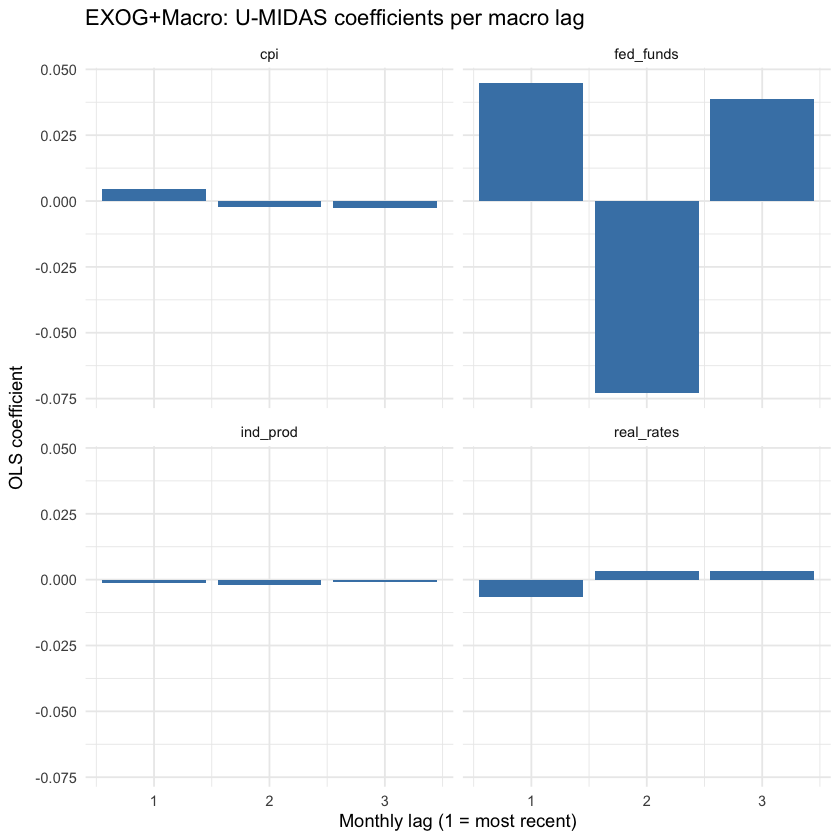

In [66]:
if (fit_em$spec == "restricted") {
  w_df <- do.call(rbind, lapply(names(fit_em$weights), function(v) {
    w <- fit_em$weights[[v]]
    data.frame(var = v, lag = seq_along(w), weight = w)
  }))
  ggplot(w_df, aes(x = lag, y = weight)) +
    geom_line(linewidth = 0.8, colour = "steelblue") +
    geom_point(size = 2, colour = "steelblue") +
    facet_wrap(~ var, ncol = 2) +
    labs(title = paste0("EXOG+Macro: fitted ", best_spec, " lag-weight profiles"),
         x = "Monthly lag (1 = most recent)", y = "Weight") +
    theme_minimal(base_size = 11)
} else {
  n_base <- length(EXOG_LAGS) + 1                          # +1 for intercept
  macro_coefs <- fit_em$coefs[(n_base + 1):length(fit_em$coefs)]
  c_df <- data.frame(name = fit_em$macro_names, coef = macro_coefs)
  c_df$var <- sub("_mlag[0-9]+$", "", c_df$name)
  c_df$lag <- as.integer(sub(".*_mlag", "", c_df$name))
  ggplot(c_df, aes(x = lag, y = coef)) +
    geom_col(fill = "steelblue") +
    facet_wrap(~ var, ncol = 2) +
    labs(title = "EXOG+Macro: U-MIDAS coefficients per macro lag",
         x = "Monthly lag (1 = most recent)", y = "OLS coefficient") +
    theme_minimal(base_size = 11)
}


## 9. Period breakdown — DA / WDA by calendar year

Best variant by WDA broken down across the standard `PERIODS` from `eval_utils`.
Same year buckets as RF / XGBoost / LSTM.

In [67]:
# Pick best non-naive variant by WDA
candidates <- metrics_df[metrics_df$model != "Naive (t-1 week)", ]
best_row   <- candidates[which.max(candidates$wda), ]
best_name  <- best_row$model
best_pred  <- all_preds[[best_name]]
cat("Best variant by WDA:", best_name, "\n")

PERIODS <- list(
  "2023 (choppy)"     = c("2023-01-01", "2023-12-31"),
  "2024 (bull start)" = c("2024-01-01", "2024-12-31"),
  "2025 (bull run)"   = c("2025-01-01", "2025-12-31"),
  "2026 (YTD)"        = c("2026-01-01", "2026-12-31"),
  "── Full test ──"   = c("2023-01-01", "2026-12-31")
)

rows <- list()
for (label in names(PERIODS)) {
  bounds <- as.Date(PERIODS[[label]])
  mask   <- dates_te >= bounds[1] & dates_te <= bounds[2]
  a <- y_te[mask]; p <- best_pred[mask]
  ok <- !is.na(a) & !is.na(p)
  if (sum(ok) < 4) next
  da_v  <- mean(sign(a[ok]) == sign(p[ok]))
  wda_v <- sum(abs(a[ok]) * (sign(a[ok]) == sign(p[ok]))) / sum(abs(a[ok]))
  rows[[label]] <- data.frame(n = sum(ok), DA = da_v, WDA = wda_v)
}
period_df <- do.call(rbind, rows)
write.csv(period_df, "../../data/processed/period_midas_weekly.csv", row.names = TRUE)
print(round(period_df, 3))


Best variant by WDA: EXOG+Macro+Sentiment 
                    n    DA   WDA
2023 (choppy)      52 0.481 0.492
2024 (bull start)  52 0.500 0.570
2025 (bull run)    52 0.635 0.710
2026 (YTD)         19 0.632 0.518
── Full test ──   175 0.549 0.579


## 10. Diebold-Mariano tests

Each variant vs the `EXOG` baseline. Tests whether adding Macro (Beta-MIDAS),
sentiment, or both yields a statistically significant improvement in squared-error
loss. p < 0.05 = significant.

In [68]:
cat("Diebold-Mariano tests — each variant vs EXOG baseline\n")
cat("H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns = not significant\n")
cat(strrep("-", 90), "\n")

baseline_pred <- all_preds$"EXOG"
for (name in names(all_preds)) {
  if (name %in% c("EXOG", "Naive (t-1 week)")) next
  diebold_mariano(y_te, baseline_pred, all_preds[[name]], "EXOG", name)
}


Diebold-Mariano tests — each variant vs EXOG baseline
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns = not significant
------------------------------------------------------------------------------------------ 
EXOG                           vs EXOG+Macro                      DM=-2.605  p=0.009  **
  -> EXOG is significantly more accurate
EXOG                           vs EXOG+Reddit                     DM=-0.511  p=0.609  (ns)
EXOG                           vs EXOG+News                       DM=+1.275  p=0.202  (ns)
EXOG                           vs EXOG+Reddit+News                DM=+1.243  p=0.214  (ns)
EXOG                           vs EXOG+Macro+Sentiment            DM=-2.929  p=0.003  **
  -> EXOG is significantly more accurate


## 11. 2026 zoom — actual vs best variant

Same 2026 view as the other weekly notebooks, using the best variant by WDA.

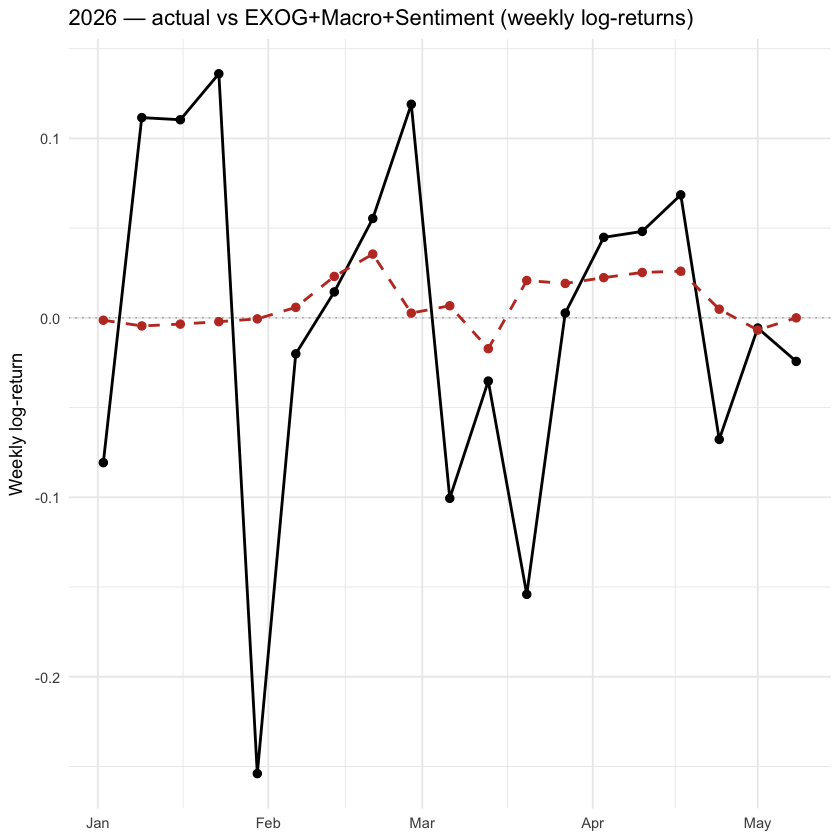

In [69]:
df26 <- data.frame(date = dates_te, actual = y_te, pred = best_pred)
df26 <- df26[df26$date >= as.Date("2026-01-01"), ]

if (nrow(df26) == 0) {
  cat("No 2026 data in test set yet.\n")
} else {
  ggplot(df26, aes(x = date)) +
    geom_hline(yintercept = 0, colour = "grey60", linewidth = 0.3, linetype = "dotted") +
    geom_line(aes(y = actual), colour = "black",  linewidth = 0.8) +
    geom_point(aes(y = actual), colour = "black", size = 2) +
    geom_line(aes(y = pred),   colour = "#c0392b", linewidth = 0.8, linetype = "dashed") +
    geom_point(aes(y = pred),  colour = "#c0392b", size = 2) +
    labs(title = paste0("2026 — actual vs ", best_name, " (weekly log-returns)"),
         x = NULL, y = "Weekly log-return") +
    theme_minimal(base_size = 11)
}
